In [1]:
# Import basics

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# Create dummy dataset

X = torch.tensor([[1.0, 2.0],
                  [2.0, 3.0],
                  [3.0, 4.0],
                  [4.0, 5.0]])

y = torch.tensor([[3.0],
                  [5.0],
                  [7.0],
                  [9.0]])

In [ ]:
# Define neural network

class SimpleNN(nn.Module):  # nn.Module -> inheritance
    def __init__(self):
        super(SimpleNN, self).__init__() # initialize parent setup
        self.fc1 = nn.Linear(2,4)
        self.fc2 = nn.Linear(4,1)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

In [4]:
# Create model + loss + optimizer

model = SimpleNN()

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)


In [5]:
# Traning loop

for epoch in range(100):

    predictions = model(X) #forward pass

    loss = criterion(predictions, y) #compute loss

    #backprop
    optimizer.zero_grad()
    loss.backward()

    #update weights
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")



Epoch 0, Loss: 39.911338806152344
Epoch 10, Loss: 0.04419952630996704
Epoch 20, Loss: 0.03916279226541519
Epoch 30, Loss: 0.034692712128162384
Epoch 40, Loss: 0.030725594609975815
Epoch 50, Loss: 0.027205387130379677
Epoch 60, Loss: 0.024082157760858536
Epoch 70, Loss: 0.02131178416311741
Epoch 80, Loss: 0.018854890018701553
Epoch 90, Loss: 0.01667678914964199


In [6]:
# Print Learned Weights

print(model.fc1.weight)
print(model.fc1.bias)

print(model.fc2.weight)
print(model.fc2.bias)


Parameter containing:
tensor([[-0.0220, -0.2198],
        [ 0.8549,  0.9041],
        [-0.3121,  0.2030],
        [ 0.5698, -0.6897]], requires_grad=True)
Parameter containing:
tensor([-0.1866,  0.3118, -0.2953,  0.3176], requires_grad=True)
Parameter containing:
tensor([[ 0.0812,  1.0786, -0.2502,  0.1930]], requires_grad=True)
Parameter containing:
tensor([-0.0152], requires_grad=True)


In [7]:
new_data = torch.tensor([[1.0, 3.0], [3.1, 4.7]])

model.eval()

with torch.no_grad():

    prediction = model(new_data)

    print(prediction)

tensor([[4.1683],
        [7.7629]])



(process:6036): Pango-WARNING **: 23:06:33.491: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


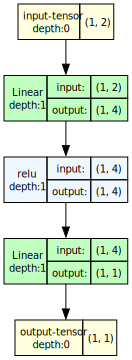

In [8]:
from torchview import draw_graph

graph = draw_graph(
    model,
    input_size=(1, 2),
    expand_nested=True
)

graph.visual_graph